In [1]:
!pip install pandas scikit-learn

In [153]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import dump

In [3]:
df = pd.read_csv('wildfire_data_cleaned.csv')

In [4]:
print("Cleaned Dataset:")
print(df.head())

Cleaned Dataset:
   latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0   21.6927    79.1329       325.3   1.6    1.2  2002-03-17       508   
1   21.1960    81.4140       332.3   1.1    1.1  2002-03-17       508   
2   21.1910    81.4177       329.4   1.1    1.1  2002-03-17       508   
3   21.1583    80.1179       326.3   1.3    1.1  2002-03-17       508   
4   22.3539    76.5043       323.5   2.5    1.5  2002-03-17       508   

   bright_t31   frp  type  year  month  day  
0       311.9  10.1     0  2002      3   17  
1       315.5  16.3     2  2002      3   17  
2       314.4  14.1     2  2002      3   17  
3       313.6  11.9     0  2002      3   17  
4       309.2  29.6     0  2002      3   17  


In [12]:
df = df.drop(columns=['acq_date'])

In [138]:
num_bins = 45
df['frp_class'] = pd.cut(df['frp'], bins=num_bins, labels=False)

In [139]:
df['frp_class'] = df['frp_class'].astype(int)

In [140]:
print("\nDistribution of FRP Classes:")
print(df['frp_class'].value_counts())


Distribution of FRP Classes:
frp_class
0     188109
1      14619
2       2940
3        983
4        418
5        229
6        103
7         72
8         41
9         32
10        20
12        12
11         9
13         7
14         5
15         5
17         4
16         3
18         1
27         1
44         1
Name: count, dtype: int64


In [141]:
X = df.drop(['frp', 'frp_class'], axis=1)
y = df['frp_class']

In [142]:
print("\nFeatures (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())


Features (X):
   latitude  longitude  brightness  scan  track  acq_time  bright_t31  type  \
0   21.6927    79.1329       325.3   1.6    1.2       508       311.9     0   
1   21.1960    81.4140       332.3   1.1    1.1       508       315.5     2   
2   21.1910    81.4177       329.4   1.1    1.1       508       314.4     2   
3   21.1583    80.1179       326.3   1.3    1.1       508       313.6     0   
4   22.3539    76.5043       323.5   2.5    1.5       508       309.2     0   

   year  month  day  
0  2002      3   17  
1  2002      3   17  
2  2002      3   17  
3  2002      3   17  
4  2002      3   17  

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: frp_class, dtype: int64


In [143]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [145]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [146]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [147]:
y_pred = model.predict(X_test)

In [148]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")


Model Accuracy: 0.97


In [136]:
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nTraining Accuracy: {train_accuracy:.2f}")


Training Accuracy: 1.00


In [137]:
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")

Test Accuracy: 0.97


In [149]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     37642
           1       0.86      0.83      0.85      2916
           2       0.82      0.76      0.79       593
           3       0.76      0.68      0.72       197
           4       0.58      0.47      0.52        72
           5       0.38      0.55      0.45        33
           6       0.53      0.40      0.46        20
           7       0.33      0.19      0.24        16
           8       0.50      0.13      0.21        15
           9       0.00      0.00      0.00         7
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         1
   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_


Confusion Matrix:


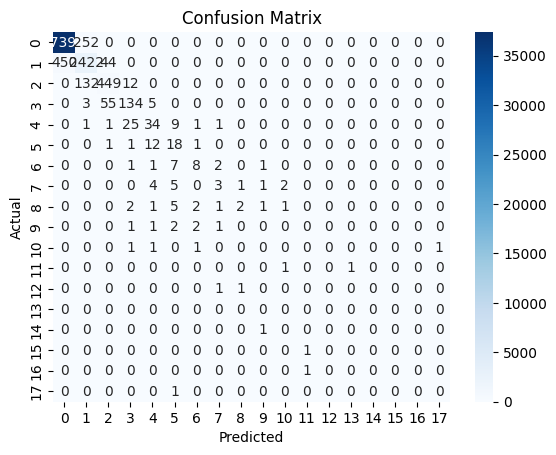

In [150]:
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [154]:
dump(model, 'wildfire_model.joblib')
print("Model saved as 'wildfire_model.joblib'.")

Model saved as 'wildfire_model.joblib'.
